# Projet CSAA - Classification du rythme cardiaque issu d'ECG


Ce jeu de données est composé d'une collections de signaux de battements cardiaques provenant d'un jeu de données célèbres dans le domaine de la classification des battements cardiaques, le jeu de données sur l'arythmie du MIT-BIH.

Les signaux correspondent à des formes d'électrocardiogramme (ECG) de battements cardiaques pour le cas normal et les cas affectés par différentes arythmies et infarctus du myocarde. Ces signaux sont prétraités et segmentés, chaque segment correspondant à un battement cardiaque.

<img src="./DataECG.png" width="800" height="600">

On distingue 5 battements cardiaques différents : Battements normaux', 'Battements inconnus', 'Battements ectopiques ventriculaires', 'Battements ectopiques supraventriculaires' et 'Battements de fusion'.

De ces signaux, on extrait des caractéristiques par la librairie TSFEL - *Time Series Features Extraction Library* (https://tsfel.readthedocs.io/en/latest/index.html)

Les 156 caractéristiques extraites sont divisées selon les domaines :
- temporel avec 31 caractéristiques comme l'entropie, Max, Min, Absolute Energy ...
- statistique avec 14 caractéristiques comme écart moyen absolu, écart médian, variance, Kurtosis...
- spectral  avec 111 caractéristiques comme les coefficients FFT par bande de fréquence, ondelettes...

Lien vers le papier expliquant TSFEL : https://www.sciencedirect.com/science/article/pii/S2352711020300017

In [35]:
# Librairies utiles
import numpy as np
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement des données d'apprentissage et de test

In [36]:
# Chargement des données brutes 
DataECGFull=np.load('./DataECG.npy')
print('Taille du dataset ECG:', DataECGFull.shape)

# Après extraction des features
# Chargement des données d'apprentissage
DataFeature=np.load('./DataFeature.npy')
Label=np.load('./Label.npy')
print('Taille du dataset après extraction de features :', DataFeature.shape, Label.shape)





# Séparation en ensemble d'apprentissage et de test 
from sklearn.model_selection import train_test_split

DataECGApp, DataECGTest, Label_train, Label_test = train_test_split(DataECGFull, Label, test_size=0.2, random_state=42)
DataFeatureApp, DataFeatureTest, LabelF_train, LabelF_test = train_test_split(DataFeature, Label, test_size=0.2, random_state=42)

print('Taille de la base d apprentissage ECG :', DataECGApp.shape, 'Taille du dataset de test ECG :', DataECGTest)


print('Taille de la base d apprentissage Features :', DataFeatureApp.shape, 'Taille du dataset de test Features :', DataFeatureApp.shape)


Taille du dataset ECG: (5000, 188)
Taille du dataset après extraction de features : (5000, 156) (5000,)
Taille de la base d apprentissage ECG : (4000, 188) Taille du dataset de test ECG : [[1.         0.76923078 0.09615385 ... 0.         0.         1.        ]
 [0.02783726 0.01284797 0.         ... 0.         0.         2.        ]
 [0.77732795 0.66126853 0.36167341 ... 0.         0.         2.        ]
 ...
 [1.         0.96815288 0.79617834 ... 0.         0.         3.        ]
 [0.         0.07518797 0.20451128 ... 0.         0.         2.        ]
 [0.52471483 0.23574145 0.07984791 ... 0.         0.         1.        ]]
Taille de la base d apprentissage Features : (4000, 156) Taille du dataset de test Features : (4000, 156)


# Chargement des variables issues *TSFEL*

In [37]:
ListeVariablesStat=np.load('./ListeVariableStat.npy',allow_pickle=True)
print('Nombre de variables statistiques :',ListeVariablesStat.shape)
print('Liste Variables Statistiques :', ListeVariablesStat)

ListeVariablesTemps=np.load('./ListeVariableTemps.npy',allow_pickle=True)
print('Nombre de variables temporelles :',ListeVariablesTemps.shape)
print('Liste Variables Temporelles :',ListeVariablesTemps)

ListeVariablesSpectral=np.load('./ListeVariableSpectral.npy',allow_pickle=True)
print('Nombre de variables spectrales :',ListeVariablesSpectral.shape)
print('Liste Variables Spectrales :',ListeVariablesSpectral)

Nombre de variables statistiques : (31,)
Liste Variables Statistiques : ['0_Absolute energy' '0_Average power' '0_ECDF Percentile Count_0'
 '0_ECDF Percentile Count_1' '0_ECDF Percentile_0' '0_ECDF Percentile_1'
 '0_ECDF_0' '0_ECDF_1' '0_ECDF_2' '0_ECDF_3' '0_ECDF_4' '0_ECDF_5'
 '0_ECDF_6' '0_ECDF_7' '0_ECDF_8' '0_ECDF_9' '0_Entropy'
 '0_Histogram mode' '0_Interquartile range' '0_Kurtosis' '0_Max' '0_Mean'
 '0_Mean absolute deviation' '0_Median' '0_Median absolute deviation'
 '0_Min' '0_Peak to peak distance' '0_Root mean square' '0_Skewness'
 '0_Standard deviation' '0_Variance']
Nombre de variables temporelles : (14,)
Liste Variables Temporelles : ['0_Area under the curve' '0_Autocorrelation' '0_Centroid'
 '0_Mean absolute diff' '0_Mean diff' '0_Median absolute diff'
 '0_Median diff' '0_Negative turning points' '0_Neighbourhood peaks'
 '0_Positive turning points' '0_Signal distance' '0_Slope'
 '0_Sum absolute diff' '0_Zero crossing rate']
Nombre de variables spectrales : (111,)
Liste 

### Fonctions pour réaliser une table de correspondance entre le label des approches non supervisées et le label réel

In [38]:
def retrieve_info(cluster_labels,y_train):
 #Associe l'étiquette la plus probable à chaque groupe dans le modèle KMeans.
 #Résultats : dictionnaire des clusters associés à chaque étiquette.

# Initialisation
  reference_labels = np.zeros((len(np.unique(cluster_labels)),1))
# Loop pour chaque label
  for i in range(len(np.unique(cluster_labels))):
    index = np.where(cluster_labels == i,1,0)
    num = np.bincount(y_train[index==1]).argmax()
    reference_labels[i] = num
  return reference_labels

def correspondance(y_pred_kmeans,y_train):
  # Correspondance entre la partition et les classes de la vérité terrain
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels


# Partie I : Implémentation de l'algorithme de programmation dynamique (DTW)

1. Ecrivez une fonction en python DTW qui implémente le calcul et l'affichage de la matrice des coûts définie en TD. 



In [6]:
from math import *
import numpy as np
import sys

In [7]:



def dtwp(A, B, w0=1, w1=2, w2=1):
    
    N, M = len(A), len(B)
    
    # Initialisation de la matrice des coûts cumulés avec des valeurs infinies
    g = np.full((N + 1, M + 1), np.inf)
    g[0, 0] = 0  
    
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            d_ij = abs(A[i - 1] - B[j - 1])
            g[i, j] = min(
                g[i - 1, j] + w0 * d_ij,       # Chemin haut
                g[i - 1, j - 1] + w1 * d_ij,  # Chemin diagonale
                g[i, j - 1] + w2 * d_ij       # Chemin gauche
            )
    
    S = g[N, M] / (N + M)
    
    return S, g





In [8]:

A = [1,2,3,4,5]
B = [1,3,2,5,4]
score, cost_matrix = dtwp(A, B)


print("Score d'alignement :", score)

print("Matrice des coûts cumulés :\n", cost_matrix)

Score d'alignement : 0.5
Matrice des coûts cumulés :
 [[ 0. inf inf inf inf inf]
 [inf  0.  2.  3.  7. 10.]
 [inf  1.  2.  2.  5.  7.]
 [inf  3.  1.  2.  4.  5.]
 [inf  6.  2.  4.  4.  4.]
 [inf 10.  4.  7.  4.  5.]]


## Système de reconnaissance de battements cardiaques par DTW



**Système de reconnaissance :**
Pour chaque profil temporel test :

a) Calculer pour chaque classe, le score de la DTW entre le profil temporel test et les profils temporels de la classe 

b) Déterminer la classe d'appartenance par minimum du score sur toutes les classes


In [10]:

import numpy as np
from dtw import dtw  # Bibliothèque pour DTW
from sklearn.metrics import accuracy_score
# Système de reconnaissance à partir de la DTW
TAILLE_TEST = len(DataECGTest)
N_CLASSES = len(np.unique(Label_train))
PartitionDTW=np.zeros((TAILLE_TEST*N_CLASSES,2))

print('Taille de la partition DTW :', PartitionDTW.shape)
print('Nombre de classes :', N_CLASSES)



## à coder

# Boucle pour calculer la distance DTW et effectuer la classification
for i in range(DataECGTest.shape[0]):
    dict_score = {}  # Stocker les distances moyennes par classe
    for j in range(DataECGApp.shape[0]):
        score = dtw(DataECGApp[j, :], DataECGTest[i, :]).distance
        dict_score[Label_train[j]] = dict_score.get(Label_train[j], []) + [score]
    
    # Moyenne des distances pour chaque classe
    for label, list_score in dict_score.items():
        dict_score[label] = np.mean(list_score)
    
    # Prédiction de la classe avec la plus petite distance moyenne
    PartitionDTW[i, 1] = min(dict_score.keys(), key=dict_score.get)








Taille de la partition DTW : (5000, 2)
Nombre de classes : 5


KeyboardInterrupt: 

**Evaluation :** A partir de la partition de l'ensemble test obtenue après la DTW, calculer la matrice de confusion qui recense le nombre de données bien classés et mal classés.

In [9]:
# Evaluation des résultats par matrices de confusion 
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [7]:
print('Matrice de confusion par DTW')
cm=confusion_matrix(PartitionDTW[:,0],PartitionDTW[:,1])
sns.heatmap(data=cm,fmt='.0f',xticklabels=np.unique(classe[:N_CLASSES]),yticklabels=np.unique(classe[:N_CLASSES]),annot=True)

# score de performance
print('Accuracy sur base de test :',accuracy_score(PartitionDTW[:,0],PartitionDTW[:,1]))

Matrice de confusion par DTW


NameError: name 'PartitionDTW' is not defined

# Partie II : Classification des battements cardiaques sur les features sans prétraitement

Réaliser une classification des battements cardiaques par une méthode d'apprentissage supervisé et une méthode d'apprentissage non supervisé de votre choix en utilisant la librairie *scikit-learn*.

Pour chaque résultat obtenu, calculer la matrice de confusion et interpréter les résultats.


## Méthodes supervisées  :
indiquer quelles sont les 2 méthodes supervisées de votre choix et calculer la matrice de confusion associée.

## Forêt d’arbres décisionnels

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Entraînement du modèle Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(DataFeatureApp, LabelF_train)

# Prédictions
y_pred_rf = model_rf.predict(DataFeatureTest)

# Calcul de la matrice de confusion
conf_matrix_rf = confusion_matrix(LabelF_test, y_pred_rf)
print("Matrice de confusion :\n", conf_matrix_rf)





Matrice de confusion :
 [[195   6  11   1   3]
 [ 23 164   3   0   0]
 [  7   1 178   6   0]
 [  0   0   2 208   0]
 [  5   2   4   0 181]]


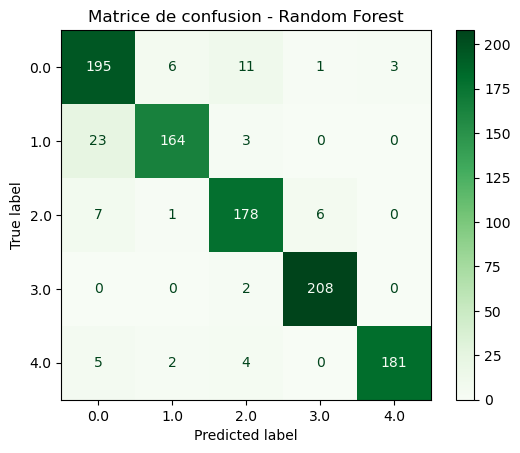

In [46]:
# Affichage avec scikit-learn
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=np.unique(Label))
disp.plot(cmap="Greens", values_format="d")
plt.title("Matrice de confusion - Random Forest")
plt.show()

In [47]:
# Rapport de classification
print("Rapport de classification :\n", classification_report(LabelF_test, y_pred_rf))

Rapport de classification :
               precision    recall  f1-score   support

         0.0       0.85      0.90      0.87       216
         1.0       0.95      0.86      0.90       190
         2.0       0.90      0.93      0.91       192
         3.0       0.97      0.99      0.98       210
         4.0       0.98      0.94      0.96       192

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## Réseau de Neurones (ANN)

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Création du modèle ANN
model_ann = Sequential([
    Dense(128, input_dim=DataFeatureApp.shape[1], activation='relu'),  
    Dropout(0.2),  
    Dense(64, activation='relu'), 
    Dense(len(np.unique(Label)), activation='softmax')  
])

# Compilation du modèle
model_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
history = model_ann.fit(DataFeatureApp, LabelF_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Évaluation sur l'ensemble de test
loss, accuracy = model_ann.evaluate(DataFeatureTest, LabelF_test)
print(f"Précision du modèle ANN : {accuracy:.2f}")






Epoch 1/100


c:\Users\elgue\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2494 - loss: 120.0597 - val_accuracy: 0.4550 - val_loss: 7.9943
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3165 - loss: 27.9220 - val_accuracy: 0.5188 - val_loss: 7.1329
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3966 - loss: 13.2187 - val_accuracy: 0.5525 - val_loss: 4.4417
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4598 - loss: 7.2285 - val_accuracy: 0.5013 - val_loss: 4.2059
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5027 - loss: 4.4414 - val_accuracy: 0.6338 - val_loss: 2.0897
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5475 - loss: 2.6635 - val_accuracy: 0.6662 - val_loss: 1.3794
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5870 - loss: 1.8854 - val_accuracy: 0.6700 - val_loss: 1.1136
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6067 - loss: 1.4537 - val_accuracy: 0.

In [51]:
# Prédictions
y_pred_ann = model_ann.predict(DataFeatureTest)
y_pred_ann_classes = y_pred_ann.argmax(axis=1)

# Calcul de la matrice de confusion
conf_matrix_ann = confusion_matrix(LabelF_test, y_pred_ann_classes)
print("Matrice de confusion - ANN :\n", conf_matrix_ann)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Matrice de confusion - ANN :
 [[176   9  17   8   6]
 [ 52 132   4   2   0]
 [ 11   1 163   9   8]
 [  8   1   7 193   1]
 [  6   4   8   3 171]]


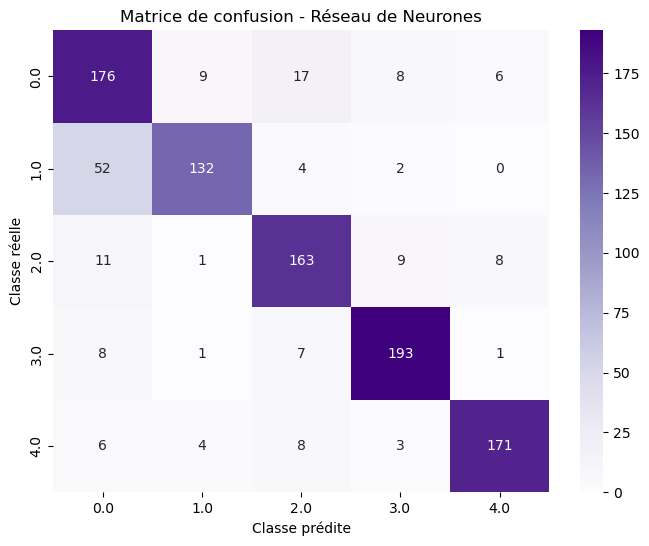

Rapport de classification - ANN :
               precision    recall  f1-score   support

         0.0       0.70      0.81      0.75       216
         1.0       0.90      0.69      0.78       190
         2.0       0.82      0.85      0.83       192
         3.0       0.90      0.92      0.91       210
         4.0       0.92      0.89      0.90       192

    accuracy                           0.83      1000
   macro avg       0.85      0.83      0.84      1000
weighted avg       0.84      0.83      0.84      1000



In [52]:
# Visualisation de la matrice de confusion avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ann, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Réseau de Neurones")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Rapport de classification
print("Rapport de classification - ANN :\n", classification_report(LabelF_test, y_pred_ann_classes))


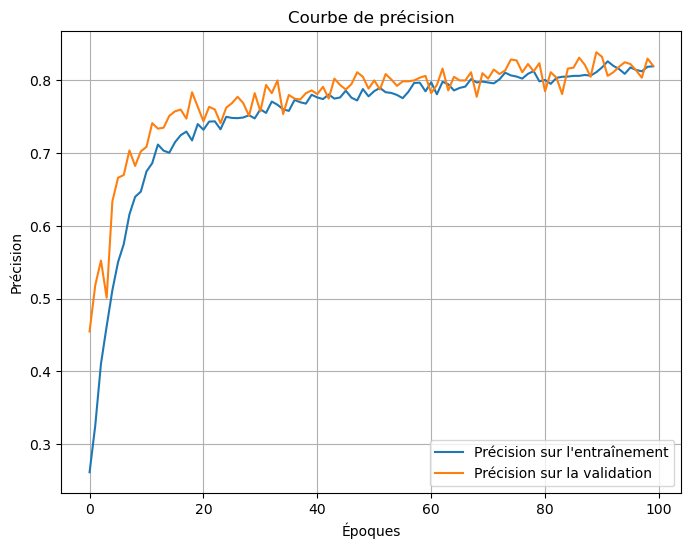

In [53]:
# Tracé de la courbe de précision
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Précision sur l\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision sur la validation')
plt.title("Courbe de précision")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.grid()
plt.show()


## Méthodes non supervisées

Indiquer quelles sont les 2 méthodes non supervisées de votre choix et calculer la matrice de confusion associée.

## K-means

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


n_clusters = len(np.unique(Label))  # Number of unique labels as the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(DataFeature)

KMeans(n_clusters=5, random_state=42)

C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  number_labels[i] = reference_labels[y_pred_kmeans[i]]


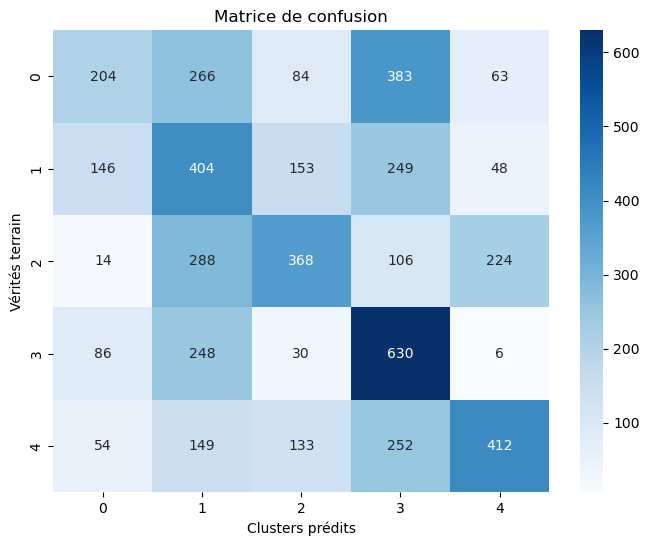

Accuracy: 0.4036


In [55]:
# Predicted cluster labels
predicted_clusters = kmeans.labels_

predicted_clusters = predicted_clusters.astype(int)

Label = Label.astype(int)

# Assign predicted clusters to their corresponding true labels
final_labels = correspondance(predicted_clusters, Label)



# Confusion matrix
conf_matrix = confusion_matrix(Label, final_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()

# Calculate accuracy
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")



In [56]:
# Calculate accuracy
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")

# Classification report
classification_report_knn = classification_report(Label, final_labels)
print("Classification Report:\n", classification_report_knn)

# Recognition rate
print('Accuracy avec K-means: ', accuracy)

Accuracy: 0.4036
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.20      0.27      1000
           1       0.30      0.40      0.34      1000
           2       0.48      0.37      0.42      1000
           3       0.39      0.63      0.48      1000
           4       0.55      0.41      0.47      1000

    accuracy                           0.40      5000
   macro avg       0.42      0.40      0.40      5000
weighted avg       0.42      0.40      0.40      5000

Accuracy avec K-means:  0.4036


##  Classification Hiérarchique

In [57]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

n_clusters = len(np.unique(Label))  # Number of unique labels as the number of clusters

# Applying Hierarchical Clustering
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(DataFeature)



C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  number_labels[i] = reference_labels[y_pred_kmeans[i]]


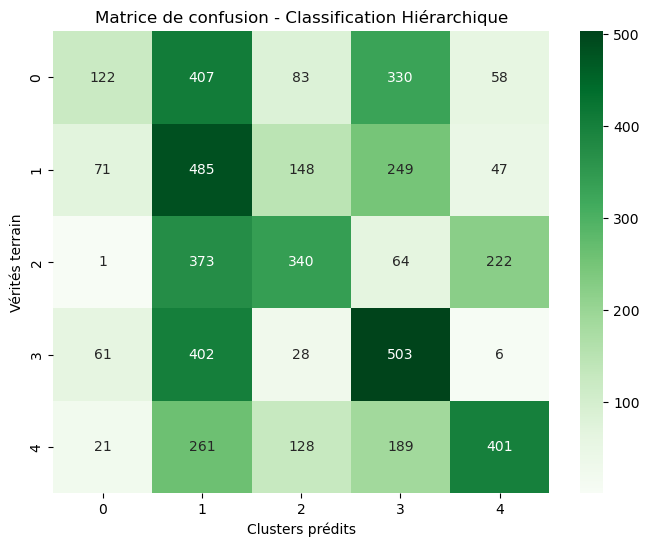

In [58]:
hierarchical_labels = hierarchical_labels.astype(int)
Label = Label.astype(int)

# Map hierarchical clusters to true labels
final_labels_hierarchical = correspondance(hierarchical_labels, Label)

# Confusion matrix for Hierarchical Clustering
conf_matrix_hierarchical = confusion_matrix(Label, final_labels_hierarchical)

# Plot confusion matrix for Hierarchical Clustering
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_hierarchical, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Classification Hiérarchique")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()



In [59]:
# Calculate accuracy for Hierarchical Clustering
accuracy_hierarchical = accuracy_score(Label, final_labels_hierarchical)
print(f"Accuracy avec Classification Hiérarchique: {accuracy_hierarchical}")

# Classification report for Hierarchical Clustering
classification_report_hierarchical = classification_report(Label, final_labels_hierarchical)
print("Classification Report - Classification Hiérarchique:\n", classification_report_hierarchical)

Accuracy avec Classification Hiérarchique: 0.3702
Classification Report - Classification Hiérarchique:
               precision    recall  f1-score   support

           0       0.44      0.12      0.19      1000
           1       0.25      0.48      0.33      1000
           2       0.47      0.34      0.39      1000
           3       0.38      0.50      0.43      1000
           4       0.55      0.40      0.46      1000

    accuracy                           0.37      5000
   macro avg       0.42      0.37      0.36      5000
weighted avg       0.42      0.37      0.36      5000



# Partie III : classification des battements cardiaques sur les features avec prétraitement par ACP

## Méthode supervisée avec réduction de dimension par ACP sur l'ensemble d'apprentissage
Réaliser une ACP sur l'ensemble d'apprentissage pour réduire la dimension, visualiser les données
puis projeter les données de l'ensemble de test dans la base de l'ACP.

Indiquer quelles sont les 2 méthodes supervisées de votre choix et calculer la matrice de confusion associée (confusion_matrix) et le score de performance (accuracy_score)

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [61]:


# Normalisation des données avec StandardScaler
scaler = StandardScaler()
DataFeature_normalized = scaler.fit_transform(DataFeature)
DataFeatureApp_normalized = scaler.fit_transform(DataFeatureApp)
DataFeatureTest_normalized = scaler.transform(DataFeatureTest)

# Réduction de dimension avec ACP (3 composantes)
pca = PCA(n_components=3)
DataFeature_PCA = pca.fit_transform(DataFeature_normalized)
DataFeatureApp_PCA = pca.fit_transform(DataFeatureApp_normalized)
DataFeatureTest_PCA = pca.transform(DataFeatureTest_normalized)


In [62]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd


data = pd.DataFrame({
    'AXE 1': DataFeatureApp_PCA[:, 0],
    'AXE 2': DataFeatureApp_PCA[:, 1],
    'AXE 3': DataFeatureApp_PCA[:, 2],
    'Classe': LabelF_train
})

In [63]:
fig = go.Figure()


for classe in np.unique(LabelF_train):
    filtered_data = data[data['Classe'] == classe]
    fig.add_trace(go.Scatter3d(
        x=filtered_data['AXE 1'],
        y=filtered_data['AXE 2'],
        z=filtered_data['AXE 3'],
        mode='markers',
        marker=dict(size=5),
        name=f'Classe {classe}'
    ))

fig.update_layout(
    title='Projection des données en 3D dans l’espace ACP',
    scene=dict(
        xaxis_title='AXE 1',
        yaxis_title='AXE 2',
        zaxis_title='AXE 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
    
)

fig.show()

### Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Classification avec Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(DataFeatureApp_PCA, LabelF_train)
Label_pred_rf = rf.predict(DataFeatureTest_PCA)


In [65]:
# Random Forest
cm_rf = confusion_matrix(LabelF_test, Label_pred_rf)
acc_rf = accuracy_score(LabelF_test, Label_pred_rf)
print("Matrice de confusion (Random Forest) :\n", cm_rf)

# report de classification
print("Rapport de classification (Random Forest) :\n", classification_report(LabelF_test, Label_pred_rf))



Matrice de confusion (Random Forest) :
 [[129  47  22   7  11]
 [ 21 153   5   7   4]
 [ 10   3 156  10  13]
 [  3   1   1 205   0]
 [  7   7  14   3 161]]
Rapport de classification (Random Forest) :
               precision    recall  f1-score   support

         0.0       0.76      0.60      0.67       216
         1.0       0.73      0.81      0.76       190
         2.0       0.79      0.81      0.80       192
         3.0       0.88      0.98      0.93       210
         4.0       0.85      0.84      0.85       192

    accuracy                           0.80      1000
   macro avg       0.80      0.81      0.80      1000
weighted avg       0.80      0.80      0.80      1000



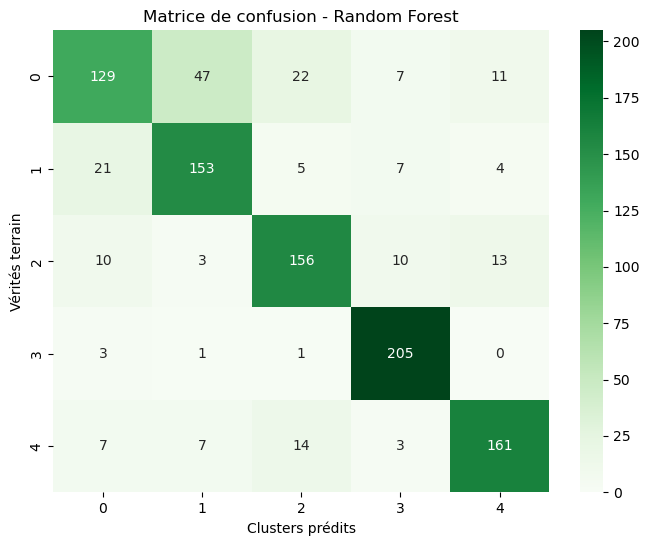

In [66]:
# Plot confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()

# Classification report for Random Forest
classification_report_rf = classification_report(LabelF_test, Label_pred_rf)


### Réseau de Neurones (ANN)

In [67]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Création du modèle ANN
model_ann = Sequential([
    Dense(128, input_dim=DataFeatureApp_PCA.shape[1], activation='relu'),  
    Dropout(0.2),  
    Dense(64, activation='relu'), 
    Dense(len(np.unique(Label)), activation='softmax')  
])

# Compilation du modèle
model_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
history = model_ann.fit(DataFeatureApp_PCA, LabelF_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Évaluation sur l'ensemble de test
loss, accuracy = model_ann.evaluate(DataFeatureTest_PCA, LabelF_test)
print(f"Précision du modèle ANN : {accuracy:.2f}")






Epoch 1/100


c:\Users\elgue\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5046 - loss: 1.2685 - val_accuracy: 0.6450 - val_loss: 0.9550
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6600 - loss: 0.9405 - val_accuracy: 0.6650 - val_loss: 0.9151
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6625 - loss: 0.8993 - val_accuracy: 0.6687 - val_loss: 0.9114
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6877 - loss: 0.8698 - val_accuracy: 0.7100 - val_loss: 0.8603
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6973 - loss: 0.8590 - val_accuracy: 0.6862 - val_loss: 0.8523
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6923 - loss: 0.8611 - val_accuracy: 0.7225 - val_loss: 0.8392
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7082 - loss: 0.8293 - val_accuracy: 0.7050 - val_loss: 0.8423
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7142 - loss: 0.7987 - val_accuracy: 0.7100

In [68]:
# Prédictions
y_pred_ann = model_ann.predict(DataFeatureTest_PCA)
y_pred_ann_classes = y_pred_ann.argmax(axis=1)

# Calcul de la matrice de confusion
conf_matrix_ann = confusion_matrix(LabelF_test, y_pred_ann_classes)
print("Matrice de confusion - ANN :\n", conf_matrix_ann)

# report de classification
print("Rapport de classification - ANN :\n", classification_report(LabelF_test, y_pred_ann_classes))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Matrice de confusion - ANN :
 [[ 96  72  31  11   6]
 [ 23 144  10  10   3]
 [ 10   4 156  14   8]
 [  6   0  11 192   1]
 [  6   8  15   5 158]]
Rapport de classification - ANN :
               precision    recall  f1-score   support

         0.0       0.68      0.44      0.54       216
         1.0       0.63      0.76      0.69       190
         2.0       0.70      0.81      0.75       192
         3.0       0.83      0.91      0.87       210
         4.0       0.90      0.82      0.86       192

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.74      1000
weighted avg       0.75      0.75      0.74      1000



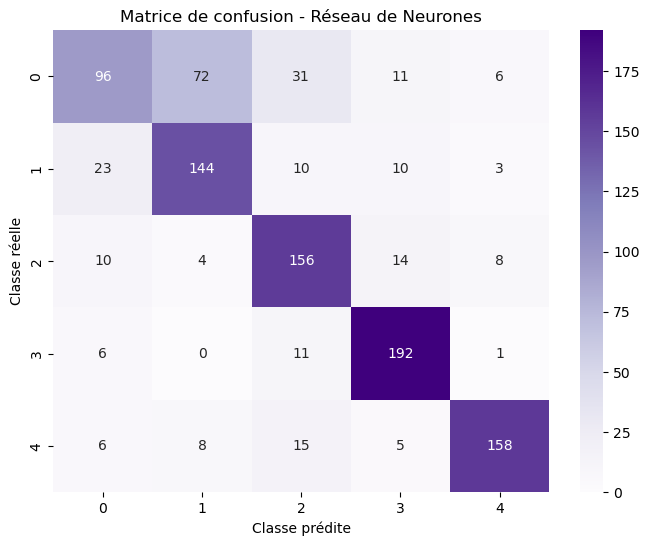

Rapport de classification - ANN :
               precision    recall  f1-score   support

         0.0       0.68      0.44      0.54       216
         1.0       0.63      0.76      0.69       190
         2.0       0.70      0.81      0.75       192
         3.0       0.83      0.91      0.87       210
         4.0       0.90      0.82      0.86       192

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.74      1000
weighted avg       0.75      0.75      0.74      1000



In [69]:

# Visualisation de la matrice de confusion avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ann, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Réseau de Neurones")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Rapport de classification
print("Rapport de classification - ANN :\n", classification_report(LabelF_test, y_pred_ann_classes))


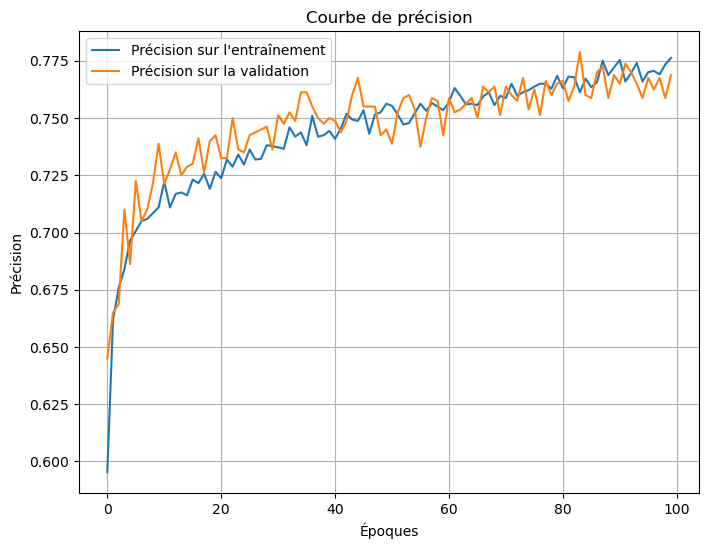

In [70]:
# Tracé de la courbe de précision
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Précision sur l\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision sur la validation')
plt.title("Courbe de précision")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.grid()
plt.show()


## Méthode non supervisée avec réduction de dimension par ACP sur l'ensemble des données

Réaliser une ACP sur l'ensemble des données et indiquer quelles sont les méthodes non supervisées de votre choix et calculer la matrice de confusion associée (confusion_matrix) et le score de performance (accuracy_score)

### K-means

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


# K-means
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(DataFeature_PCA)

C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



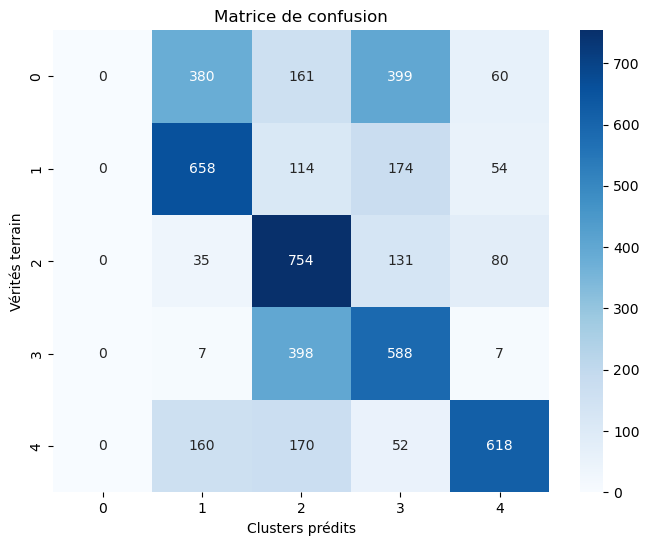

Accuracy: 0.5236


In [72]:
# Calcul de la matrice de confusion

# Predicted cluster labels
predicted_clusters = kmeans.labels_

# predicted_clusters en flot
predicted_clusters = predicted_clusters.astype(int)
Label = Label.astype(int)

# Assign predicted clusters to their corresponding true labels
final_labels = correspondance(predicted_clusters, Label)

# Confusion matrix
conf_matrix = confusion_matrix(Label, final_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()

# Calculate accuracy
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")


In [73]:
# Calculate accuracy
print(final_labels)
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")

# Classification report
classification_report_knn = classification_report(Label, final_labels)
print("Classification Report:\n", classification_report_knn)

# Recognition rate
print('Accuracy avec K-means: ', accuracy)

[3. 2. 1. ... 4. 2. 4.]
Accuracy: 0.5236
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.53      0.66      0.59      1000
           2       0.47      0.75      0.58      1000
           3       0.44      0.59      0.50      1000
           4       0.75      0.62      0.68      1000

    accuracy                           0.52      5000
   macro avg       0.44      0.52      0.47      5000
weighted avg       0.44      0.52      0.47      5000

Accuracy avec K-means:  0.5236


c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



##  Classification Hiérarchique

In [75]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

n_clusters = len(np.unique(Label))  # Number of unique labels as the number of clusters

# Applying Hierarchical Clustering
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(DataFeature_PCA)



5000


C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



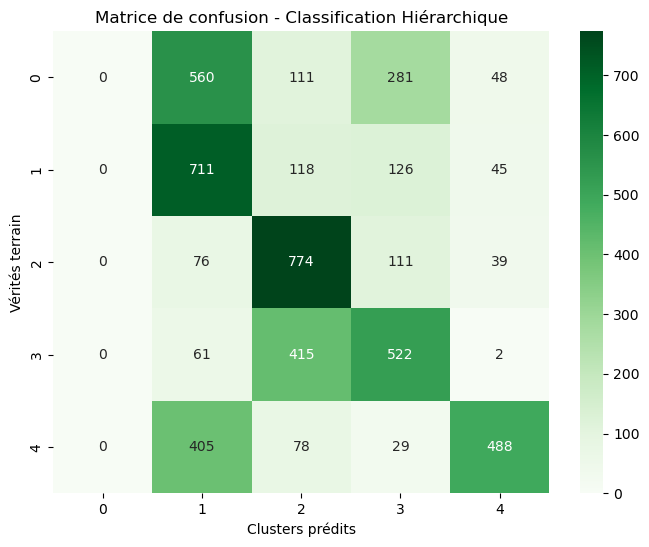

In [ ]:
hierarchical_labels = hierarchical_labels.astype(int)
Label = Label.astype(int)


# Map hierarchical clusters to true labels
final_labels_hierarchical = correspondance(hierarchical_labels, Label)

# Confusion matrix for Hierarchical Clustering
conf_matrix_hierarchical = confusion_matrix(Label, final_labels_hierarchical)

# Plot confusion matrix for Hierarchical Clustering
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_hierarchical, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Classification Hiérarchique")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()



In [79]:
# Calculate accuracy for Hierarchical Clustering
accuracy_hierarchical = accuracy_score(Label, final_labels_hierarchical)
print(f"Accuracy avec Classification Hiérarchique: {accuracy_hierarchical}")

# Classification report for Hierarchical Clustering
classification_report_hierarchical = classification_report(Label, final_labels_hierarchical)
print("Classification Report - Classification Hiérarchique:\n", classification_report_hierarchical)

Accuracy avec Classification Hiérarchique: 0.499
Classification Report - Classification Hiérarchique:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.39      0.71      0.51      1000
           2       0.52      0.77      0.62      1000
           3       0.49      0.52      0.50      1000
           4       0.78      0.49      0.60      1000

    accuracy                           0.50      5000
   macro avg       0.44      0.50      0.45      5000
weighted avg       0.44      0.50      0.45      5000



c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




# Réaliser votre étude :

- Etudier les meilleurs paramètres pour les méthodes supervisées et non supervisées que vous avez choisies.
- Faire une étude sur les paramètres issus de TSFEL en séparant par exemple les différentes modalités (statistiques,temporelles et spectrales) ou en étudiant leur correlation et essayer de réaliser des prétraitements.
- Optimiser la réduction de dimensions par ACP


### séparation des paramètres issus de TSFEL

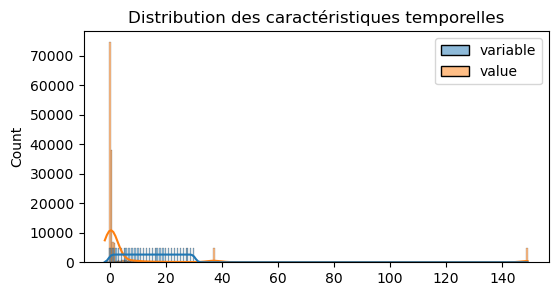

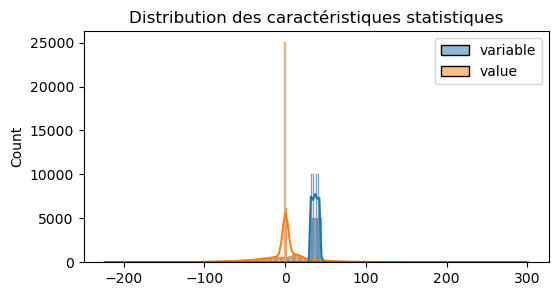

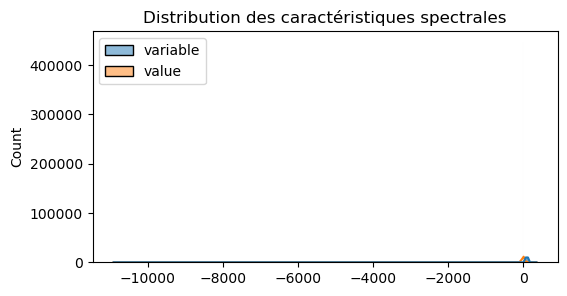

In [6]:
dataFeatureFrame = pd.DataFrame(DataFeature)
#print(dataFeatureFrame.head())

temporalFeatures = dataFeatureFrame.columns[:31] #31 caractéristiques temporelles
statiFeatures = dataFeatureFrame.columns[31:45] #14 caractéristiques statistiques
spectralFeatures = dataFeatureFrame.columns[45:] #111 caractéristiques spectrales

# Affichage des distributions
plt.figure(figsize=(6, 3))
sns.histplot(dataFeatureFrame[temporalFeatures].melt(), kde=True)
plt.title("Distribution des caractéristiques temporelles")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(dataFeatureFrame[statiFeatures].melt(), kde=True)
plt.title("Distribution des caractéristiques statistiques")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(dataFeatureFrame[spectralFeatures].melt(), kde=True)
plt.title("Distribution des caractéristiques spectrales")
plt.show()





### Corrélation des paramètres issus de TSFEL

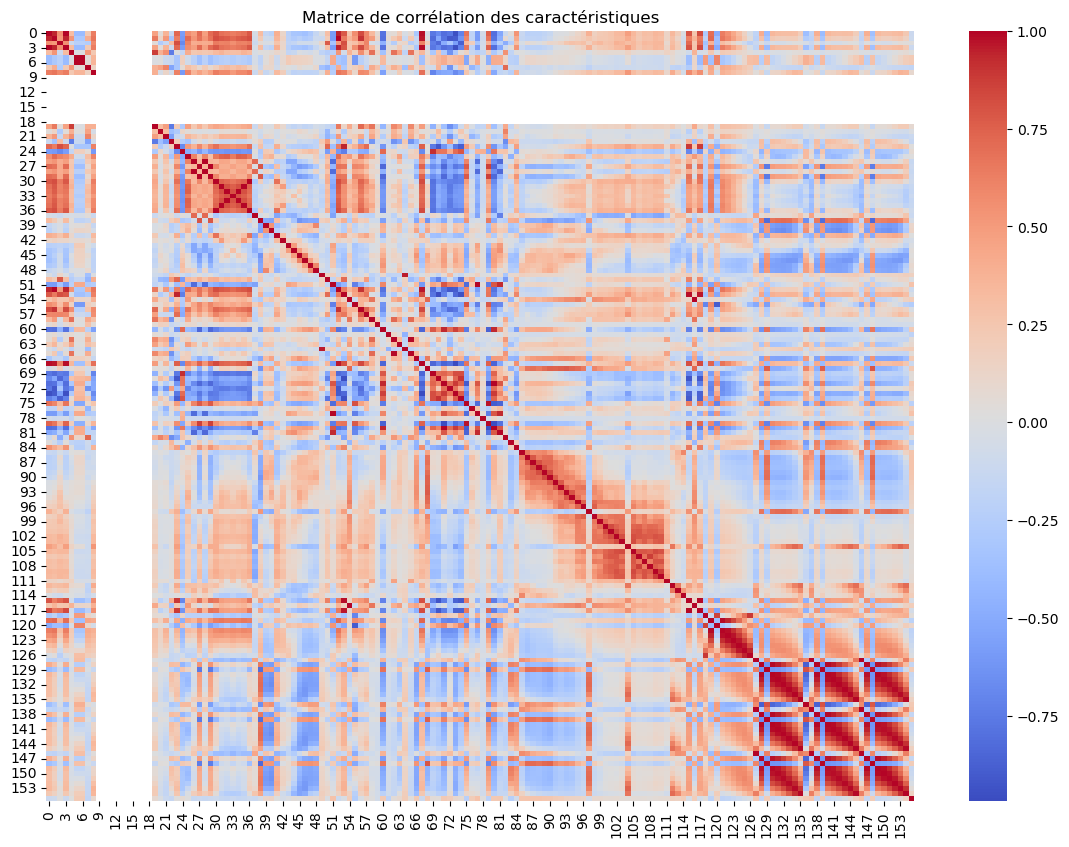

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analyse de la corrélation
plt.figure(figsize=(14, 10))
corr_matrix = dataFeatureFrame.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Matrice de corrélation des caractéristiques")
plt.show()



### Suppression des caractéristiques trop corrélées

In [10]:
threshold = 0.9  # Seuil de corrélation
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr_features = set()

for (feature1, feature2), corr_value in corr_pairs.items():
    if corr_value > threshold and feature1 != feature2:
        high_corr_features.add(feature1)

dataFeatureCorre = dataFeatureFrame.drop(columns=high_corr_features)
print(f"Caractéristiques supprimées en raison d'une forte corrélation : {high_corr_features}")

Caractéristiques supprimées en raison d'une forte corrélation : {0, 129, 1, 3, 132, 5, 6, 135, 134, 137, 133, 139, 131, 141, 142, 143, 144, 145, 140, 130, 146, 148, 149, 147, 152, 153, 26, 27, 28, 29, 30, 31, 32, 128, 34, 35, 36, 154, 49, 51, 52, 53, 54, 138, 56, 60, 62, 64, 65, 67, 23, 70, 71, 69, 73, 74, 75, 72, 77, 79, 80, 81, 24, 115, 116, 117, 150, 119, 151, 121, 122, 123, 124, 125, 126, 127}


In [11]:
# affichage des caractéristiques restantes
print(dataFeatureCorre.head())

    2         4         7         8         9         10        11       12   \
0   3.0  0.836990  0.016548  0.066194  0.005348  0.010695  0.016043  0.02139   
1   5.0  0.861621  0.000000  0.212264  0.005348  0.010695  0.016043  0.02139   
2  38.0  0.575912  0.000000  0.491089  0.005348  0.010695  0.016043  0.02139   
3  40.0  0.344452  0.000000  0.405714  0.005348  0.010695  0.016043  0.02139   
4   2.0  0.583014  0.000000  0.120172  0.005348  0.010695  0.016043  0.02139   

        13        14   ...           109           110           111  \
0  0.026738  0.032086  ...  7.883948e-07  5.931685e-07  1.022767e-06   
1  0.026738  0.032086  ...  2.630833e-06  3.036299e-06  9.638535e-07   
2  0.026738  0.032086  ...  2.074570e-06  2.472498e-06  6.156142e-07   
3  0.026738  0.032086  ...  5.527102e-06  9.520447e-06  8.122070e-06   
4  0.026738  0.032086  ...  9.354660e-07  9.337482e-07  1.627513e-06   

        112       113       114       118       120       136  155  
0  0.001224  0.00

### Optimisation de la réduction de dimensions par ACP

#### Normalisation et standardisation

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


scaler_standard = StandardScaler()

DataFeature_standard = pd.DataFrame(scaler_standard.fit_transform(dataFeatureCorre), columns=dataFeatureCorre.columns)

print("Données normalisées avec StandardScaler : " , DataFeature_standard.head())  # Affichage des données normalisées avec StandardScaler

Données normalisées avec MinMaxScaler :          2         4         7         8    9    10   11   12   13   14   ...  \
0  0.022222  0.663092  0.022037  0.070604  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  0.066667  0.682779  0.000000  0.226407  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  0.800000  0.454417  0.000000  0.523810  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  0.844444  0.269415  0.000000  0.432747  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  0.000000  0.460093  0.000000  0.128179  0.0  0.0  0.0  0.0  0.0  0.0  ...   

        109       110       111       112       113       114       118  \
0  0.005822  0.006678  0.004772  0.360717  0.357991  0.398035  0.430736   
1  0.019481  0.034301  0.004497  0.427588  0.332496  0.529940  0.495823   
2  0.015357  0.027926  0.002872  0.548094  0.567008  0.509482  0.503183   
3  0.040954  0.107613  0.037901  0.025932  0.144693  0.413830  0.409869   
4  0.006912  0.010528  0.007594  0.254642  0.225031  0.390760  0.348093   

        120       136      

#### Réduction de la dimensionnalité

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # Garde 95% de la variance
DataFeature_pca = pca.fit_transform(DataFeature_standard)

print(f"Nombre de composants PCA conservés : {pca.n_components_}")
print("data: ", DataFeature_pca)


DataFeaturePCAApp, DataFeaturePCATest, LabelFPCA_train, LabelFPCA_test = train_test_split(DataFeature_pca, Label, test_size=0.2, random_state=42)




Nombre de composants PCA conservés : 40
data:  [[-2.92455805 -2.1520574   1.84750949 ... -0.59464859  0.07040325
  -0.19444058]
 [-2.40824754 -0.10274909  2.38214328 ... -0.28692402  0.29731296
  -0.14522336]
 [ 1.11910178 -0.71805589 -0.39340303 ... -0.75604953  0.48545156
  -0.01085732]
 ...
 [-1.20088376  4.08967368  0.82687802 ...  0.51374073  0.03855092
  -0.01824238]
 [-0.69848384 -0.51558406 -0.71078134 ...  0.80935686 -0.53531661
   0.04056111]
 [ 2.74149327  2.59527596 -0.32131423 ... -0.65722217 -0.06509498
   0.08302651]]


## méthodes supervisées

### random forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Classification avec Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(DataFeaturePCAApp, LabelFPCA_train)
Label_pred_rf = rf.predict( DataFeaturePCATest)

In [15]:
cm_rf = confusion_matrix(LabelFPCA_test, Label_pred_rf)
acc_rf = accuracy_score(LabelFPCA_test, Label_pred_rf)
print("Matrice de confusion (Random Forest) :\n", cm_rf)

# report de classification
print("Rapport de classification (Random Forest) :\n", classification_report(LabelFPCA_test, Label_pred_rf))


Matrice de confusion (Random Forest) :
 [[187  10  14   3   2]
 [ 29 157   3   1   0]
 [  8   0 178   3   3]
 [  0   0   1 209   0]
 [  6   3   6   0 177]]
Rapport de classification (Random Forest) :
               precision    recall  f1-score   support

         0.0       0.81      0.87      0.84       216
         1.0       0.92      0.83      0.87       190
         2.0       0.88      0.93      0.90       192
         3.0       0.97      1.00      0.98       210
         4.0       0.97      0.92      0.95       192

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



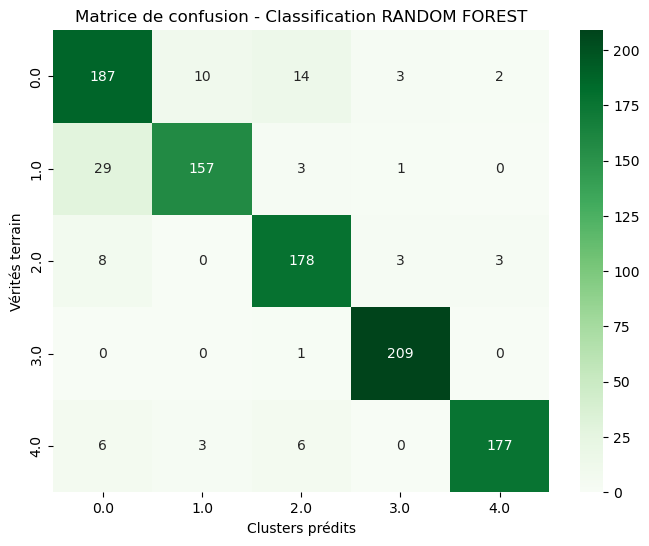

In [16]:
# Plot confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Classification RANDOM FOREST")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()

# Classification report for Random Forest
classification_report_rf = classification_report(LabelFPCA_test, Label_pred_rf)


### Réseau de Neurones (ANN)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Création du modèle ANN
model_ann = Sequential([
    Dense(128, input_dim=DataFeaturePCAApp.shape[1], activation='relu'),  
    Dropout(0.2),  
    Dense(64, activation='relu'), 
    Dense(len(np.unique(Label)), activation='softmax')  
])

# Compilation du modèle
model_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])




In [19]:
# Entraînement du modèle
history = model_ann.fit(DataFeaturePCAApp, LabelF_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)



Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5463 - loss: 1.1588 - val_accuracy: 0.7950 - val_loss: 0.5779
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8044 - loss: 0.5482 - val_accuracy: 0.8200 - val_loss: 0.4808
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8563 - loss: 0.4394 - val_accuracy: 0.8450 - val_loss: 0.4150
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8537 - loss: 0.3989 - val_accuracy: 0.8425 - val_loss: 0.4047
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3527 - val_accuracy: 0.8687 - val_loss: 0.3792
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8819 - loss: 0.3244 - val_accuracy: 0.8650 - val_loss: 0.3616
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8961 - loss: 0.2926 - val_accuracy: 0.8675 - val_loss: 0.3463
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8887 - loss: 0.2967 - val_accu

In [20]:
# Évaluation sur l'ensemble de test
loss, accuracy = model_ann.evaluate(DataFeaturePCATest, LabelFPCA_test)
print(f"Précision du modèle ANN : {accuracy:.2f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9131 - loss: 0.4305 
Précision du modèle ANN : 0.90


In [23]:
# Prédictions
y_pred_ann = model_ann.predict(DataFeaturePCATest)
y_pred_ann_classes = y_pred_ann.argmax(axis=1)

# Calcul de la matrice de confusion
conf_matrix_ann = confusion_matrix(LabelFPCA_test, y_pred_ann_classes)
print("Matrice de confusion - ANN :\n", conf_matrix_ann)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Matrice de confusion - ANN :
 [[180  23   8   2   3]
 [ 29 158   2   1   0]
 [  7   0 178   5   2]
 [  1   0   3 206   0]
 [  6   2   2   0 182]]


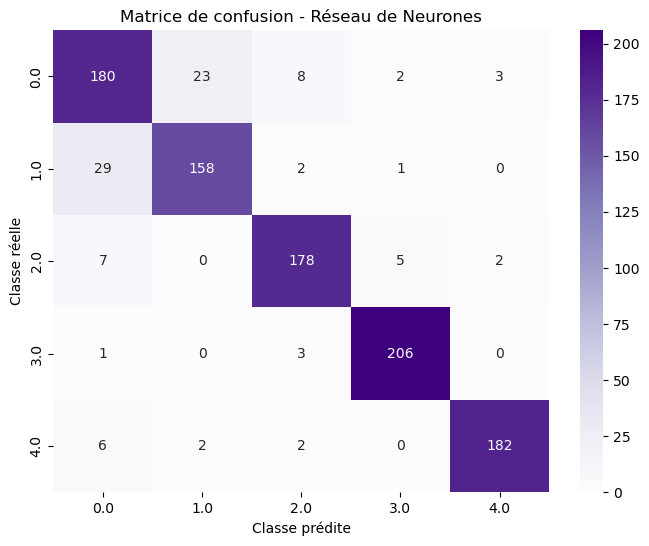

Rapport de classification - ANN :
               precision    recall  f1-score   support

         0.0       0.81      0.83      0.82       216
         1.0       0.86      0.83      0.85       190
         2.0       0.92      0.93      0.92       192
         3.0       0.96      0.98      0.97       210
         4.0       0.97      0.95      0.96       192

    accuracy                           0.90      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [24]:
# Visualisation de la matrice de confusion avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ann, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Réseau de Neurones")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Rapport de classification
print("Rapport de classification - ANN :\n", classification_report(LabelFPCA_test, y_pred_ann_classes))

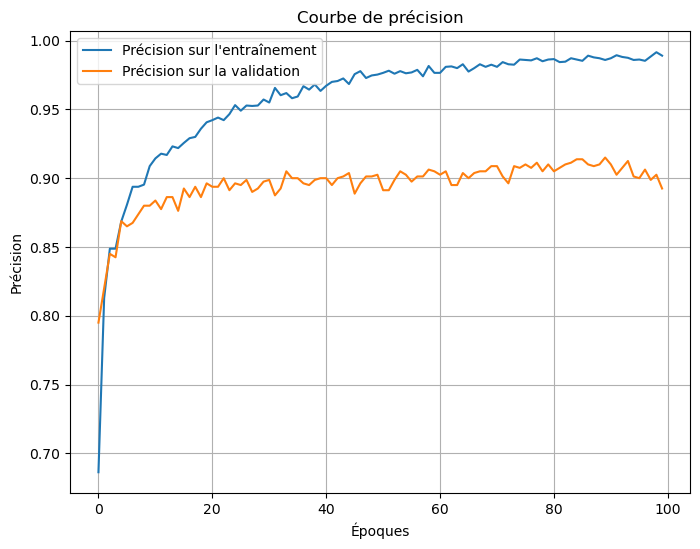

In [25]:
# Tracé de la courbe de précision
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Précision sur l\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision sur la validation')
plt.title("Courbe de précision")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.grid()
plt.show()

## méthodes non supervisées

### K-means

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


# K-means
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(DataFeature_pca)

C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  number_labels[i] = reference_labels[y_pred_kmeans[i]]


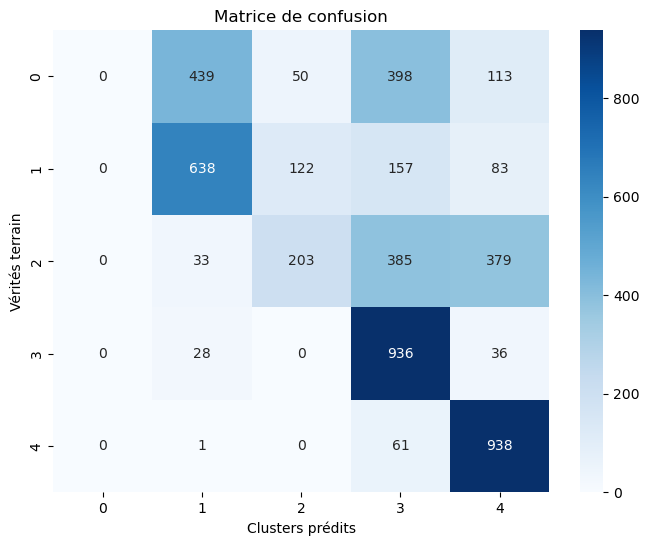

Accuracy: 0.543


In [29]:
# Calcul de la matrice de confusion

# Predicted cluster labels
predicted_clusters = kmeans.labels_

# predicted_clusters en flot

predicted_clusters = predicted_clusters.astype(int)
Label = Label.astype(int)

# Assign predicted clusters to their corresponding true labels
final_labels = correspondance(predicted_clusters, Label)

# Confusion matrix
conf_matrix = confusion_matrix(Label, final_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()

# Calculate accuracy
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")


In [30]:
# Calculate accuracy
accuracy = accuracy_score(Label, final_labels)
print(f"Accuracy: {accuracy}")

# Classification report
classification_report_knn = classification_report(Label, final_labels)
print("Classification Report:\n", classification_report_knn)

# Recognition rate
print('Accuracy avec K-means: ', accuracy)

Accuracy: 0.543
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.56      0.64      0.60      1000
           2       0.54      0.20      0.30      1000
           3       0.48      0.94      0.64      1000
           4       0.61      0.94      0.74      1000

    accuracy                           0.54      5000
   macro avg       0.44      0.54      0.45      5000
weighted avg       0.44      0.54      0.45      5000

Accuracy avec K-means:  0.543


c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Classification Hiérarchique

In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

n_clusters = len(np.unique(Label))  # Number of unique labels as the number of clusters

# Applying Hierarchical Clustering
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(DataFeature_pca)



C:\Users\elgue\AppData\Local\Temp\ipykernel_69080\2166263020.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  number_labels[i] = reference_labels[y_pred_kmeans[i]]


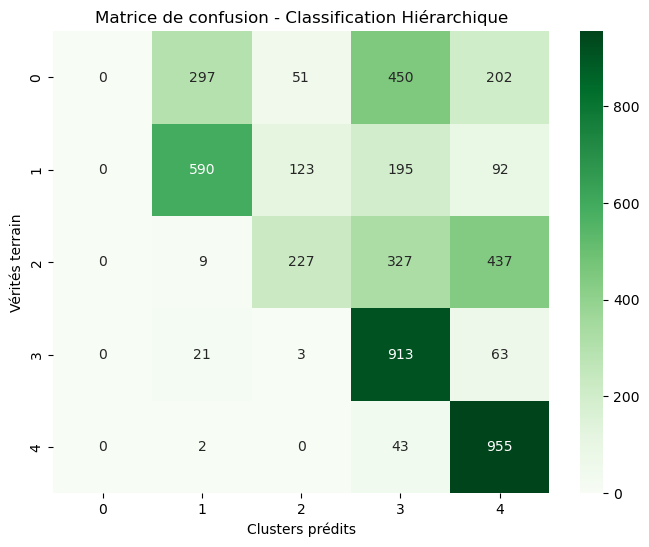

In [33]:
hierarchical_labels = hierarchical_labels.astype(int)
Label = Label.astype(int)

# Map hierarchical clusters to true labels
final_labels_hierarchical = correspondance(hierarchical_labels, Label)

# Confusion matrix for Hierarchical Clustering
conf_matrix_hierarchical = confusion_matrix(Label, final_labels_hierarchical)

# Plot confusion matrix for Hierarchical Clustering
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_hierarchical, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(Label), yticklabels=np.unique(Label))
plt.title("Matrice de confusion - Classification Hiérarchique")
plt.xlabel("Clusters prédits")
plt.ylabel("Vérités terrain")
plt.show()


In [34]:
# Calculate accuracy for Hierarchical Clustering
accuracy_hierarchical = accuracy_score(Label, final_labels_hierarchical)
print(f"Accuracy avec Classification Hiérarchique: {accuracy_hierarchical}")

# Classification report for Hierarchical Clustering
classification_report_hierarchical = classification_report(Label, final_labels_hierarchical)
print("Classification Report - Classification Hiérarchique:\n", classification_report_hierarchical)

Accuracy avec Classification Hiérarchique: 0.537
Classification Report - Classification Hiérarchique:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.64      0.59      0.61      1000
           2       0.56      0.23      0.32      1000
           3       0.47      0.91      0.62      1000
           4       0.55      0.95      0.69      1000

    accuracy                           0.54      5000
   macro avg       0.44      0.54      0.45      5000
weighted avg       0.44      0.54      0.45      5000



c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\elgue\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
